In [1]:
import numpy as np
from typing import Callable
from hide_implementation.emplots import DataPlotter, plot_paths_of_euler_maruyama_method, nicely_plot_estimated_distribution_euler_maruyama_method, nicely_plot_ornstein_uhlenbeck, nicely_plot_ornstein_uhlenbeck_distribution

# Euler-Maruyama Method for Stochastic Differential Equations

This notebook provides an explanation of the *Euler-Maruyama method*, a fundamental numerical technique for simulating stochastic differential equations (SDEs).  


## 1. Introduction to Stochastic Differential Equations (SDEs)

A **stochastic differential equation** models the evolution of a random process over time. Unlike ordinary differential equations (ODEs), which describe deterministic dynamics, SDEs incorporate randomness through a *stochastic term* driven by a **Wiener process** (also known as Brownian motion).

The general form of an SDE is:

$$
dX = f(t, X)\,dt + g(t)\,dW_t, \qquad X(t_0) = X_0,
$$

where:

* $f(t, X)$ is the **drift coefficient**, describing the deterministic trend of the process.  
* $g(t)$ is the **diffusion coefficient**, representing the intensity of randomness.  
* $W_t$ is a **standard Wiener process**, introducing stochasticity.

<br>
<br>

The SDE above is short-hand for the following integral equation:

$$
X(t) = x(0) + \int\limits_{t_0}^{T} f( t,X ) dt + \int\limits_{t_0}^{T} g(t) dW(t)
$$

### Properties of the Wiener Process

The Wiener process, denoted by $W_t$, satisfies the following key properties:

1. **Initial condition:** $W(t_0) = 0$ almost surely.  
2. **Independent increments:** For every $t > 0$, the future increments $W(t+\Delta t) - W(t)$ (for $\Delta t > 0$) are independent of the past values $W(s)$ for $s < t$.  
3. **Gaussian increments:** The increment $W(t+\Delta t) - W(t)$ follows a normal distribution $\mathcal{N}(0, \Delta t)$.  
4. **Continuous paths:** $W(t)$ is almost surely continuous as a function of $t$.

These properties make $W_t$ the mathematical model of *idealized continuous-time random motion*.

---

## 2. The Euler-Maruyama Method

The **Euler-Maruyama method** extends the classical *Euler method* for ODEs to handle SDEs.  
The central idea is to discretize time and approximate both deterministic and stochastic components step by step.

Consider the time-discretized form of an SDE:

$$
X_{n+1} = X_n + f(t_n, X_n)\,\Delta t + g(t_n)\,\Delta W_n,
$$

where:

* $\Delta t$ is the **time step size**,  
* $\Delta W_n$ is the **Brownian increment**, modeled as a Gaussian random variable:
  $$
  \Delta W_n \sim \mathcal{N}(0, \Delta t).
  $$

In [2]:
def euler_maruyama(
        f: Callable, 
        g: Callable, 
        t0: float, 
        x0: float, 
        dt: float, 
        T: int, 
        npaths: int, 
        rng=None):
    """
    input:
    * f: drift, a function `f(t, x)` returning the trend,  
    * g: diffusion, a function `g(t, x)` returning the stochastic amplitude,  
    * t_0: initial time,
    * x_0: initial condition,  
    * dt: time step,
    * T: final time,
    * npaths: number of paths to approximate.

    output:
    * a time array containing all time points $t_n$,  
    * a matrix of numerical approximations $X_n$ at each path and each step.
    """
    n_steps = int((T - t0)/dt)
    
    if rng is None:
        rng = np.random.default_rng()

    paths = np.empty((npaths, n_steps + 1))
    paths[:, 0] = x0
    ts = [t0] + [None] * n_steps
    
    for n in range(n_steps):
        ## Note that rng.normal takes (mean, std) as arguments
        dw = rng.normal(0.0, np.sqrt(dt), size=npaths)
        paths[:,n+1] = paths[:,n] + f(ts[n], paths[:,n]) * dt + g(ts[n], paths[:,n]) * dw
        ts[n+1] = ts[n] + dt

    return np.asarray(ts), paths

if __name__ == '__main__':
    def f(t, x):
        return 2*x
    
    def g(t, x):
        return t
    
    ts, xs_em = euler_maruyama(f, g, dt=0.1, t0=0.0, T=1, npaths=2, x0=-1)
    print(ts)
    print(xs_em)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
[[-1.         -1.2        -1.40387217 -1.60240625 -1.94645822 -2.24045832
  -2.64390348 -3.43325802 -4.06331495 -5.00006566 -6.2110443 ]
 [-1.         -1.2        -1.40353912 -1.7866911  -2.23820634 -2.60006448
  -3.38672507 -4.21990868 -4.9019664  -6.75602593 -7.59647293]]


In [3]:
dp = DataPlotter(
    drift=lambda t,x: 0.1*x,
    diffusion=lambda t,x: 0.2,
    mean=None,
    std=None,
    x0=[0.0, 1.0],
    dt=[0.5, .4],
    T=1,
    npaths=1,
    euler_maruyama_function=euler_maruyama,
)

for data in dp.grid():
    print(f"x0={data.x0},\tdt={data.dt},\tt0={data.t0},\t T={data.T},\t paths={data.paths}")

x0=0.0,	dt=0.5,	t0=0.0,	 T=1,	 paths=(array([0. , 0.5, 1. ]), array([[ 0.        ,  0.08790443, -0.03570181]]))
x0=0.0,	dt=0.4,	t0=0.0,	 T=1,	 paths=(array([0. , 0.4, 0.8]), array([[ 0.        , -0.1954514 , -0.13138922]]))
x0=1.0,	dt=0.5,	t0=0.0,	 T=1,	 paths=(array([0. , 0.5, 1. ]), array([[1.        , 1.18367219, 1.28370961]]))
x0=1.0,	dt=0.4,	t0=0.0,	 T=1,	 paths=(array([0. , 0.4, 0.8]), array([[1.        , 1.03603598, 1.16878413]]))


## 2. Example 1: Line with noise depending on $t$

To get started, let's consider the stochastic differential equation (SDE) with initial condition $x(t_0) = x_0$.
$$
dX = 2\,dt + t\,dW_t,
$$ 
 

<br>

The solution at time $T$ is given by the following integral form:
$$
X_T \quad=\quad x_0 + \int_{t_0}^{T} 2\,dt + \int_{t_0}^{T} t\,dW_t
\quad=\quad x_0 + 2(T-t_0) + \int_{t_0}^{T} t\,dW_t.
$$
which gives:
* **Mean**: The stochastic integral is centered, hence:
$$
\mathbb{E}[X_T] = x_0 + 2(T-t_0).
$$
* **Variance**: By Itô isometry, 
$$
\operatorname{Var}(X_T)
= \operatorname{Var}\!\Big(\int_{t_0}^{T} t\,dW_t\Big)
= \int_{t_0}^{T} t^2\,dt
= \frac{T^3 - t_0^3}{3}.
$$


### Itô isometry

**Itô isometry** states that the Itô integral over the Weiner Process $dW_t$ preserves the $L_2$ norm in expectation.
Formally, for any square-integrable adapted process $f(t)$:
$$
\mathbb{E}\left[\left(\int_a^b f(t,X) dW_t\right)^2\right] = 
\mathbb{E}\left[\int_a^b f(t,X)^2 dt\right]
$$

### The stochastic integral is centered 

For every "nice" (adaptive) $f(t)$ stochastic process satisfying 
$\ \mathbb{E}\left[\int_0^T f(t)^2 \, dW_t\right] < \infty \ $, we have that the Itô integral
$
\ I = \int_0^T f(t) \, dW_t,\ 
$
is, in expectation, zero, ie $\ \mathbb{E}[I]=0$.

<br>

To prove this, partition the interval $[0,T]$ into $\ 0 = t_0 < t_1 < \dots < t_n = T\ $ with step size $\ \Delta t_i = t_{i+1} - t_i$. $\ $ Define $\ \Delta W_i = W_{t_{i+1}} - W_{t_i}\ $ and consider the Riemann-Itô sum approximation:

$$
S_n = \sum_{i=0}^{n-1} f(t_i) \, \Delta W_i,
$$

By definition of the Itô integral:

$$
\int_0^T f(t) \, dW_t = \lim_{n \to \infty} S_n
$$


The expectation of $S_n$ is

$$
\mathbb{E}[S_n] = \mathbb{E}\left[\sum_{i=0}^{n-1} f(t_i) \, \Delta W_i \right] = \sum_{i=0}^{n-1} \mathbb{E}[ f(t_i) \, \Delta W_i ] = 0.
$$

By linearity of expectation and $L^2$-convergence of the Riemann–Itô sums:

$$
\mathbb{E}\left[ \int_0^T f(t) \, dW_t \right] = \mathbb{E}\left[ \lim_{n \to \infty} S_n \right] = \lim_{n \to \infty} \mathbb{E}[S_n] = 0.
$$

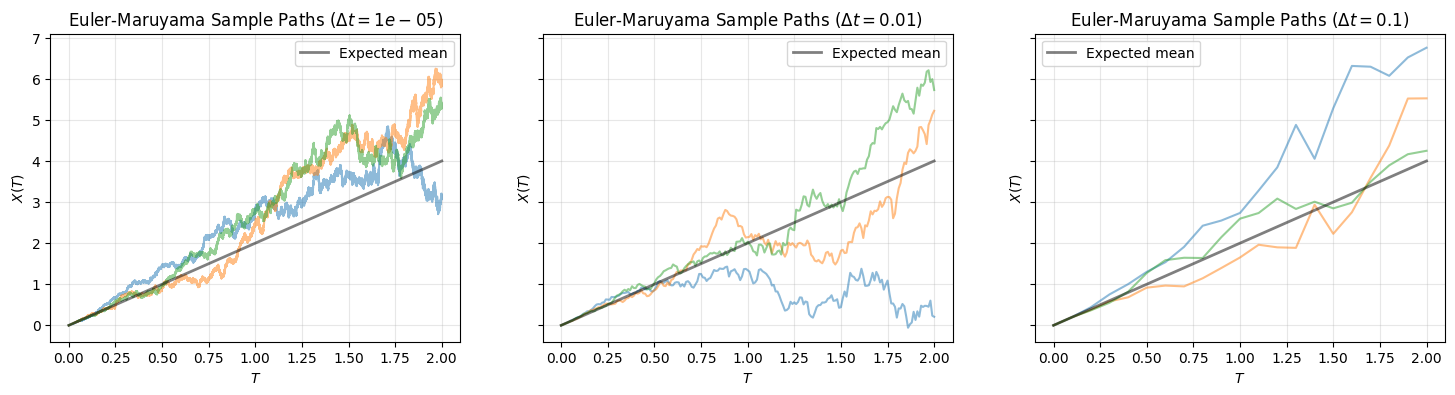

In [4]:
## Simulating few possible completions  

dp = DataPlotter(
    drift=lambda t,x: 2,
    diffusion=lambda t,x: t,
    mean=lambda x0,t0,t: x0 + 2*(t-t0),
    std=lambda t0,T: np.sqrt((T**3 - t0**3)/3),
    t0=0,
    T=2,
    x0=0.0,
    dt=[0.00001, 0.01, .1],
    npaths=3,
    euler_maruyama_function=euler_maruyama,
)

plot_paths_of_euler_maruyama_method(dp.grid())

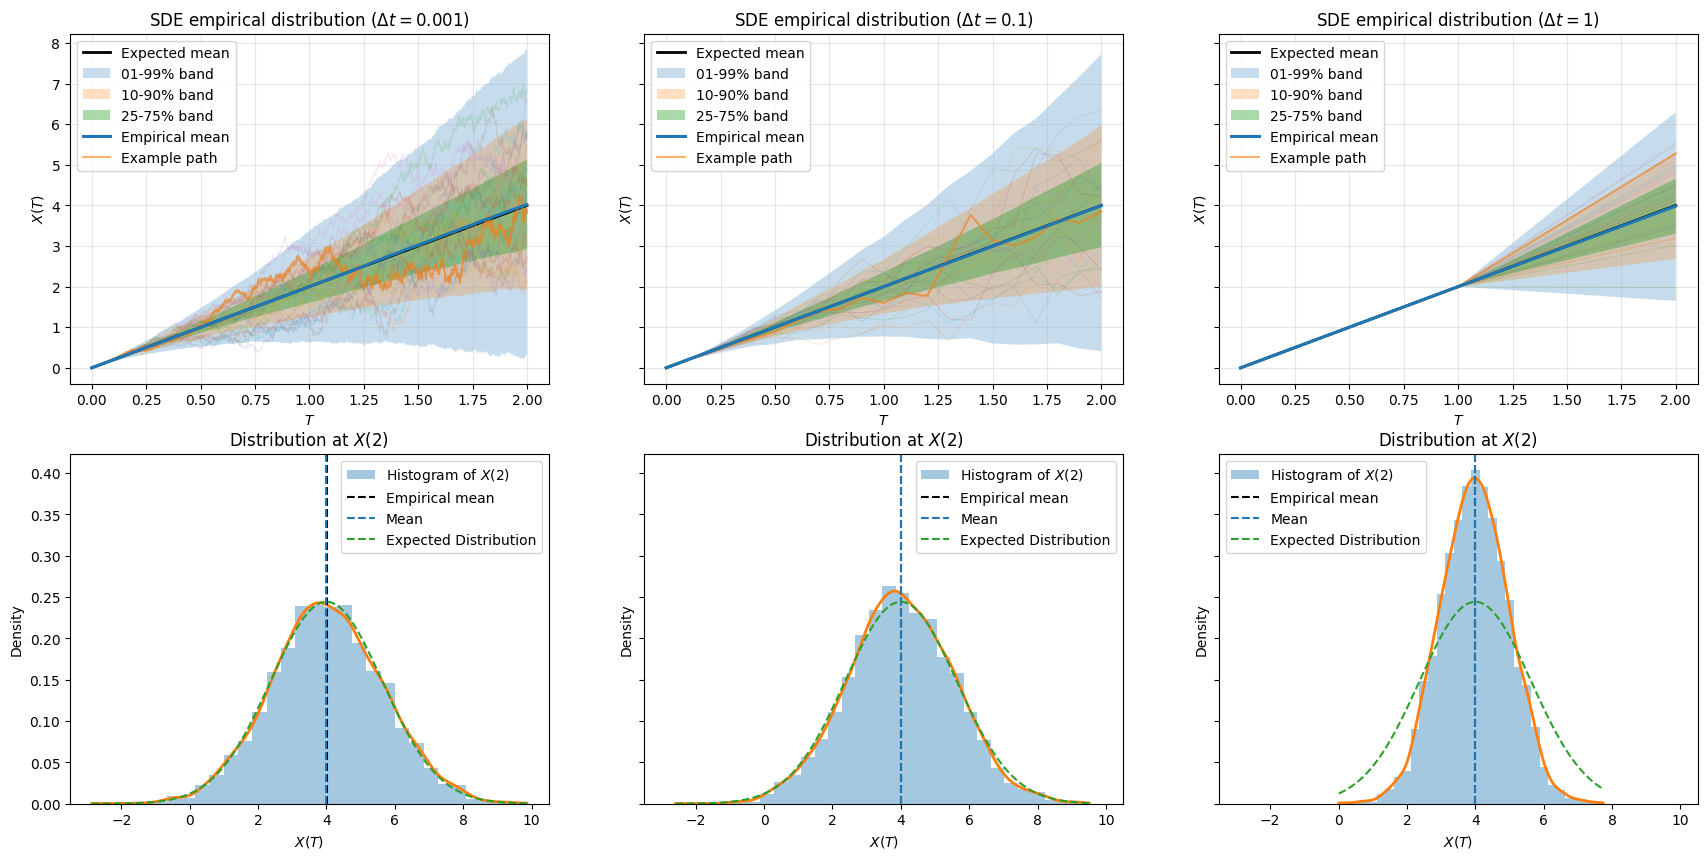

In [5]:
dp = DataPlotter(
    drift=lambda t,x: 2,
    diffusion=lambda t,x: t,
    mean=lambda x0,t0,t: x0 + 2*(t-t0),
    std=lambda t0,T: np.sqrt((T**3 - t0**3)/3),
    t0=0,
    T=2,
    x0=0,
    dt=[0.001, 0.1, 1],
    npaths=5000,
    euler_maruyama_function=euler_maruyama,
)


nicely_plot_estimated_distribution_euler_maruyama_method(dp.grid())

## 2. Example: Exponential Growth

Now, let us now simulate something more interesting than a line, to showcase the inefficiencies of first-order approximations. Consider the following SDE:
$$
dX = 2X\,dt + dW,
$$ 

<br>

The solution at time $T$ is given by the following integral form:
$$
X_T = x_0 + \int_{t_0}^{T} 2X_t\,dt + \int_{t_0}^{T} dW_t
$$

### Mean
The stochastic integral is centered, and by linearity of expectation:
$$
\mathbb{E}[X_T] = x_0 + \int_{t_0}^{T} 2\mathbb{E}[X_t]\,dt 
$$
Hence the expected value is given by the following ODE:
$$
d\mathbb{E}[X_T] = 2\mathbb{E}[X_t]\,dt \qquad \text{where: } \quad \mathbb{E}[X_T] = x_0
$$
This ODE has solution:
$$
\mathbb{E}[X_T] = x_0 e^{2(T-t_0)}
$$


### Variance

We cannot solve the variance problem as we did in Example 1. In particular:
$$
\begin{aligned}
\operatorname{Var}(X_T) 
&= \operatorname{Var}\left(x_0 + \int_{t_0}^{T} 2X_t\,dt + \int_{t_0}^{T} dW_t\right)
\\
&= \operatorname{Var}\left(\int_{t_0}^{T} 2X_t\,dt + \int_{t_0}^{T} dW_t\right)
\end{aligned}
$$
where the integral on the left is **not** deterministic (as it depends on the values of the random variable $X_t$) and must be computed to get the correct value of the variance.

<br>
<br>

To solve this impasse, define the centered process $Y_t = X_t - \mathbb{E}[X_t]$. Then $Y_t$ satisfies $
dY_t = dX_t - \mathbb{E}[dX_t] = (2X_t\,dt + dW_t) - 2\mathbb{E}[X_t]$, hence:

$$
dY_t = 2 Y_t \, dt + dW_t, \quad Y_{t_0} = 0.
$$

with initial condition $Y_{t_0}=0$. For all SDEs that can be rewritten as $\ dY_t = a(t) Y_t \, dt + b(t) \, dW_t, \quad Y_{t_0} = 0 $, the **variation of constants** formula gives an analytical solution that can be written as

$$
Y_T = \int_{t_0}^{T} \Phi(T,t) \, b(t) \, dW_t,
$$

where $\Phi(T,s)$ is the resolvent of the homogeneous ODE $\frac{d}{dt}\Phi(t,s) = a(t) \Phi(t,s), \; \Phi(s,s) = 1$.  Therefore, in our case where $a(t) = 2$ and $b(t) = 1$:
$$
\Phi(T,s) = e^{2(T-t)}, \quad \text{and hence} \quad Y_T = \int_{t_0}^{T} e^{2(T-t)} \, dW_t.
$$

By the Itô isometry, the variance is

$$
\operatorname{Var}(X_T) = \operatorname{Var}(Y_T) = \int_{t_0}^{T} \left(e^{2(T-t)}\right)^2 dt = \int_{t_0}^{T} e^{4(T-t)} \, dt.
$$

Evaluating the integral:

$$
\int_{t_0}^{T} e^{4(T-t)} \, dt = \int_{T-t_0}^{0} e^{4 u} \, (-du) = \int_{0}^{T-t_0} e^{4 u} \, du = \frac{1}{4} \left( e^{4(T-t_0)} - 1 \right),
$$

where we substituted $u = T - t$.

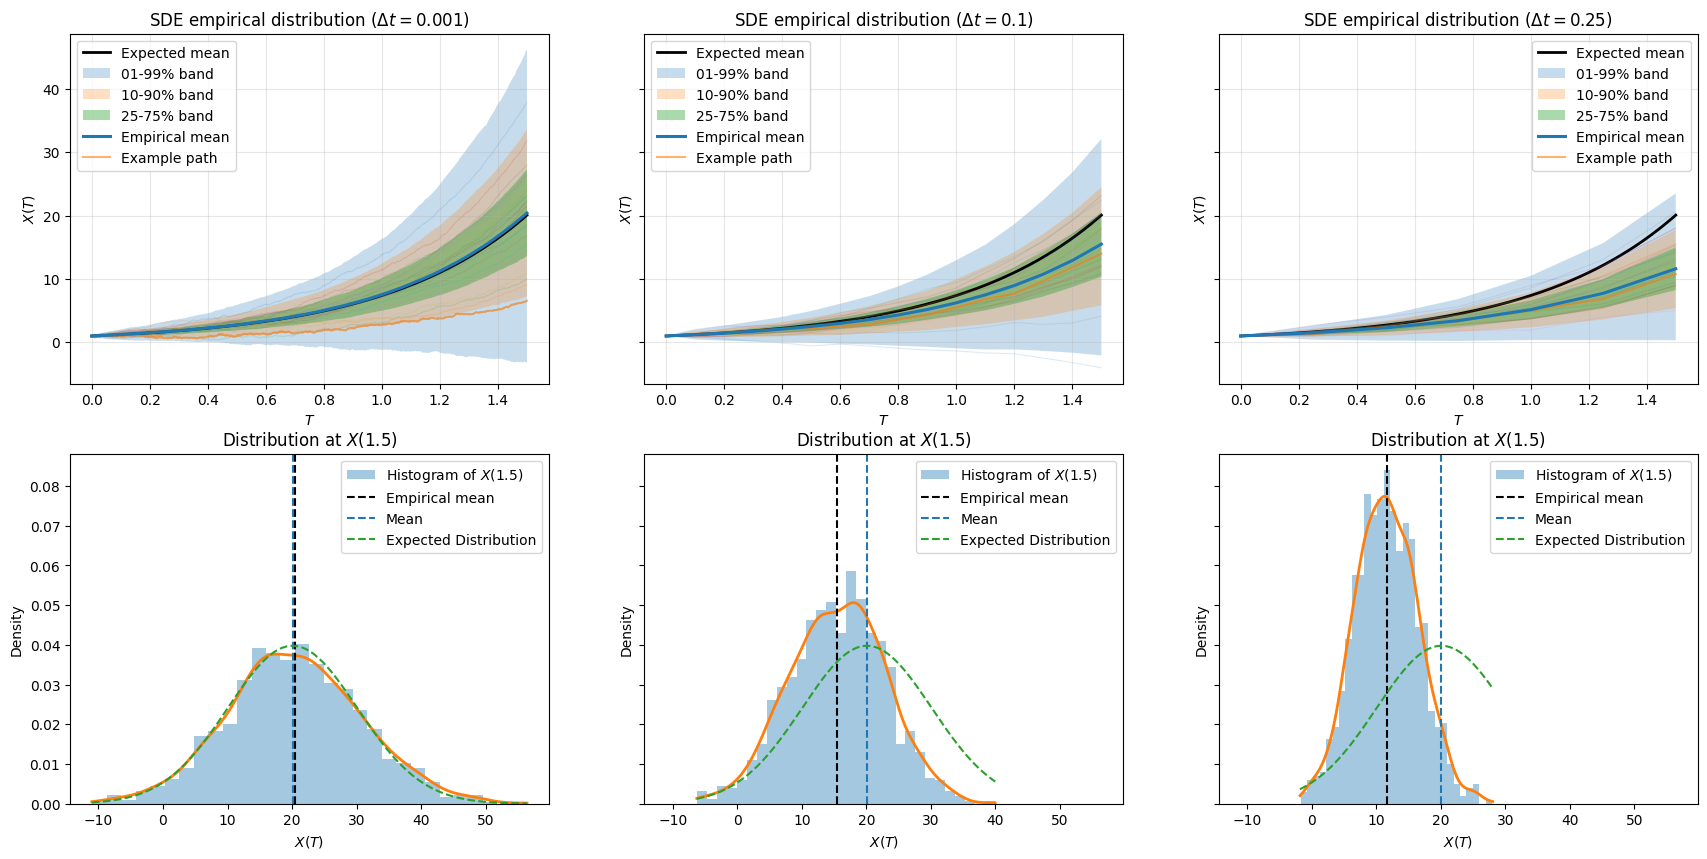

In [6]:
dp = DataPlotter(
    drift=lambda t,x: 2*x,
    diffusion=lambda t,x: 1,
    mean=lambda x0,t0,t: x0 * np.exp(2*(t-t0)),
    std=lambda t0,T: np.sqrt((np.exp(4*(T-t0))-1)/4) ,
    x0=1,
    t0=0,
    T=1.5,
    dt=[0.001, 0.1, 0.25],
    npaths=1000,
    euler_maruyama_function=euler_maruyama,
)

nicely_plot_estimated_distribution_euler_maruyama_method(dp.grid())

## Example 3: Ornstein-Uhlenbeck process

Consider the Ornstein-Uhlenbeck (OU) stochastic differential equation (SDE) with initial condition $x(t_0) = x_0$:

$$
dX = \theta (\mu - X) \, dt + \sigma \, dW_t,
$$

where $\theta > 0$ is the rate of mean reversion, $\mu$ is the long-term mean, $\sigma > 0$ is the volatility, and $W_t$ is a standard Wiener process.

<br>

The OU process is a linear SDE, and its solution can be written in integral form as

$$
X_T = x_0 + \int_{t_0}^{T} \theta (\mu - X_t) \, dt + \int_{t_0}^{T} \sigma \, dW_t.
$$

Using the **variation of constants** method, the solution has the explicit form:

$$
X_T = x_0 e^{-\theta (T-t_0)} + \mu \big(1 - e^{-\theta (T-t_0)}\big) + \sigma \int_{t_0}^{T} e^{-\theta (T-t)} \, dW_t.
$$

Where, in this formulation, we were able to remove the explicit dependence on the $X_t$ random variable from the RHS of the SDE, incorporating it in the $e^{\theta (T-t_0)}$ term by the variation of constants method.


### Mean

Taking expectation and using linearity:

$$
\mathbb{E}[X_T] = x_0 e^{-\theta (T-t_0)} + \mu \big(1 - e^{-\theta (T-t_0)}\big).
$$

Hence, the mean of the OU process **decays exponentially** from the initial value $x_0$ towards the long-term mean $\mu$ at rate $\theta$.



### Variance

Define the centered stochastic integral:

$$
Y_T = \sigma \int_{t_0}^{T} e^{-\theta (T-t)} \, dW_t.
$$

By Itô isometry, the variance is

$$
\operatorname{Var}(X_T) = \operatorname{Var}(Y_T) = \sigma^2 \int_{t_0}^{T} e^{-2\theta (T-t)} \, dt.
$$

Evaluating the integral:

$$
\int_{t_0}^{T} e^{-2\theta (T-t)} \, dt = \int_{T-t_0}^{0} e^{-2\theta (T-t)} \, (-du) = \int_{0}^{T-t_0} e^{-2\theta u} \, du = \frac{1 - e^{-2\theta (T-t_0)}}{2 \theta}.
$$

where we substituted $u = T - t$. Therefore,

$$
\operatorname{Var}(X_T) = \frac{\sigma^2}{2 \theta} \left( 1 - e^{-2\theta (T-t_0)} \right).
$$


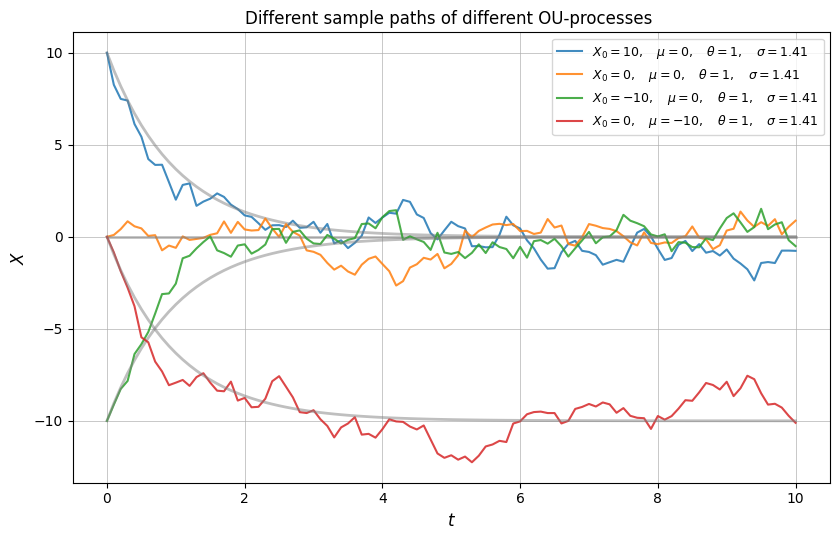

In [7]:
import numpy as np
import matplotlib.pyplot as plt
    

cases = [
    {"theta":1.0, "sigma":np.sqrt(2.0), "x0": 10.0, "mu": 0.0},
    {"theta":1.0, "sigma":np.sqrt(2.0), "x0": 0.0,  "mu": 0.0},
    {"theta":1.0, "sigma":np.sqrt(2.0), "x0": -10.0,"mu": 0.0},
    {"theta":1.0, "sigma":np.sqrt(2.0), "x0": 0.0,  "mu": -10.0},
]

meta_drift = lambda theta,mu: lambda t,x: theta*(mu - x)
meta_diffusion = lambda sigma: lambda t,x: sigma
meta_mean = lambda theta,mu: lambda x0,t0,t: x0*np.exp(-theta*(t-t0)) + mu*(1-np.exp(-theta*(t-t0)))
meta_std = lambda theta,sigma: lambda t0,t: np.sqrt(sigma*np.sqrt(1/(2*theta)(1-np.exp(-2*theta(t-t0)))))

grid = [
    (DataPlotter(
        drift = meta_drift(case["theta"], case["mu"]),
        diffusion = meta_diffusion(case["sigma"]),
        mean = meta_mean(case["theta"], case["mu"]),
        std = meta_std(case["theta"], case["sigma"]),
        x0 = case["x0"],
        t0 = 0,
        T = 10,
        dt = 0.1,
        npaths = 1,
        euler_maruyama_function=euler_maruyama,
    ), case["theta"], case["sigma"], case["mu"], euler_maruyama)
    for case in cases
]

nicely_plot_ornstein_uhlenbeck(grid)

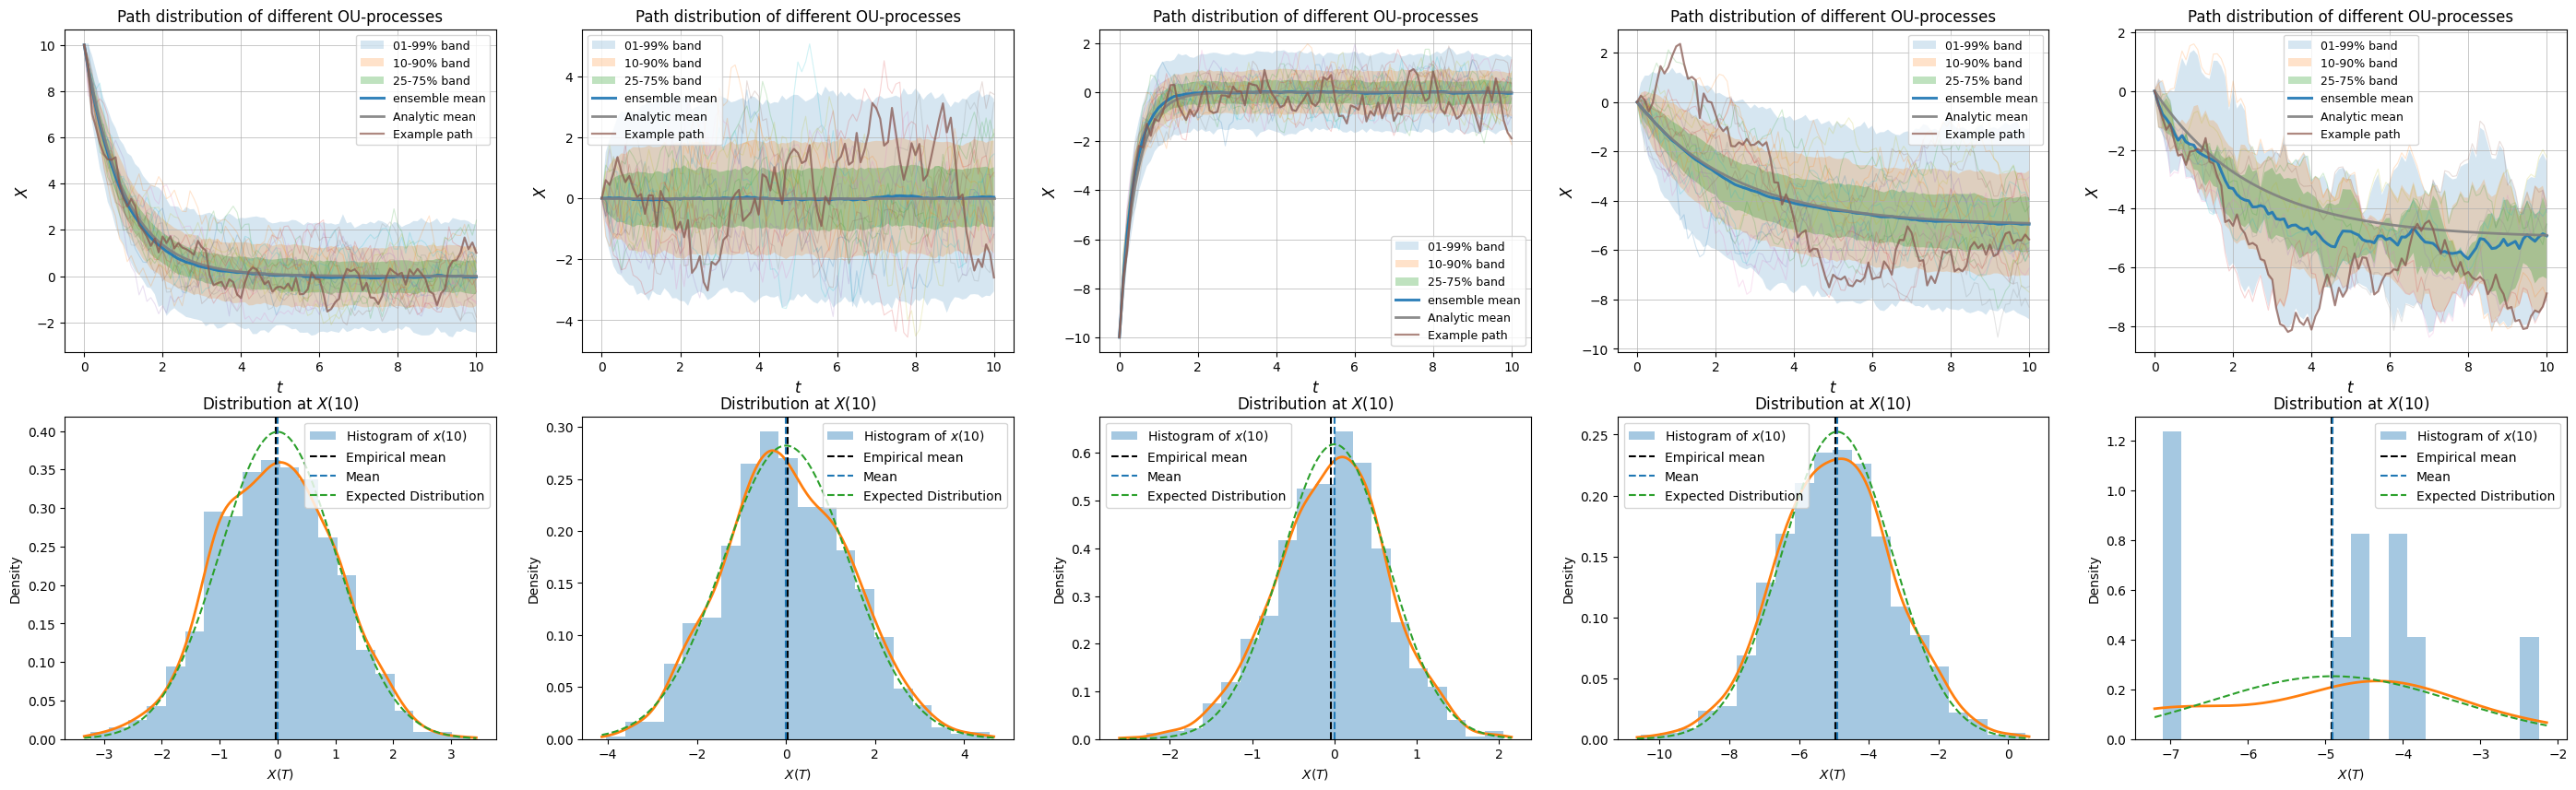

In [8]:
cases = [
    {"theta":1.0, "sigma":np.sqrt(2.0), "x0": 10.0, "mu": 0.0, "t0": 0, "T": 10, "dt": 0.1, "npaths": 1000},
    {"theta":1.0, "sigma":np.sqrt(4.0), "x0": 0.0,  "mu": 0.0, "t0": 0, "T": 10, "dt": 0.1, "npaths": 1000},
    {"theta":2.4, "sigma":np.sqrt(2.0), "x0": -10.0,"mu": 0.0, "t0": 0, "T": 10, "dt": 0.1, "npaths": 1000},
    {"theta":0.4, "sigma":np.sqrt(2.0), "x0": 0.0,  "mu": -5.0, "t0": 0, "T": 10, "dt": 0.1, "npaths": 1000},
    {"theta":0.4, "sigma":np.sqrt(2.0), "x0": 0.0,  "mu": -5.0, "t0": 0, "T": 10, "dt": 0.1, "npaths": 10},
]

meta_drift = lambda theta,mu: lambda t,x: theta*(mu - x)
meta_diffusion = lambda sigma: lambda t,x: sigma
meta_mean = lambda theta,mu: lambda x0,t0,t: x0*np.exp(-theta*(t-t0)) + mu*(1-np.exp(-theta*(t-t0)))
meta_std = lambda theta,sigma: lambda t0,t: np.sqrt(sigma**2/(2*theta)*(1-np.exp(-2*theta*(t-t0))))

grid = [
    (DataPlotter(
        drift = meta_drift(case["theta"], case["mu"]),
        diffusion = meta_diffusion(case["sigma"]),
        mean = meta_mean(case["theta"], case["mu"]),
        std = meta_std(case["theta"], case["sigma"]),
        x0 = case["x0"],
        t0 = case["t0"],
        T = case["T"],
        dt = case["dt"],
        npaths = case["npaths"],
        euler_maruyama_function=euler_maruyama,
    ), case["theta"], case["sigma"], case["mu"], euler_maruyama)
    for case in cases
]

nicely_plot_ornstein_uhlenbeck_distribution(grid)
